# Sanghelios — Perfilamiento de donantes
**Hospital General de Medellín**

Segmentación de donantes del banco de sangre mediante K-Prototypes.

| | |
|---|---|
| **Proyecto** | Sanghelios |
| **Autor** | Jose Miguel García Vélez |
| **Datos** | [df_banco_sangre_preprocessed.csv](https://github.com/Semillero-Inteligencia-Artificial-EAFIT/Sanghelios/blob/main/data/processed/df_banco_sangre_preprocessed.csv) — Banco de sangre HGM |
| **Período** | 2020 – 2025 |

---

## 0. Configuración

In [1]:
# Librerías
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes

# Estilo global
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "#FAFAFA",
        "axes.facecolor": "#FAFAFA",
        "axes.edgecolor": "#DDDDDD",
        "axes.labelcolor": "#333333",
        "xtick.color": "#444444",
        "ytick.color": "#444444",
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.8,
        "axes.titleweight": "600",
        "axes.titlesize": 12,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

PALETA = ["#185FA5", "#A32D2D", "#3B6D11", "#D49A3A", "#8E5BA3"]
MESES = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]
C_SEXO = {"f": "#A32D2D", "m": "#185FA5"}
C_CLUSTER = {0: "#A32D2D", 1: "#185FA5", 2: "#3B6D11"}


def style_axes(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    if grid_axis:
        ax.grid(axis=grid_axis, linewidth=0.6, alpha=0.6)
        ax.set_axisbelow(True)
    if title:
        ax.set_title(title, loc="left")
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#ddd")


def label_bars(
    ax, bars, labels=None, orientation="v", offset_ratio=0.03, fontsize=8, color="#444"
):
    if not len(bars):
        return
    if orientation == "v":
        heights = [b.get_height() for b in bars]
        offset = max(heights) * offset_ratio if heights else 0
        if labels is None:
            labels = [f"{h:,.0f}" for h in heights]
        for bar, lbl in zip(bars, labels):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                lbl,
                ha="center",
                va="bottom",
                fontsize=fontsize,
                color=color,
            )
    else:
        widths = [b.get_width() for b in bars]
        offset = max(widths) * offset_ratio if widths else 0
        if labels is None:
            labels = [f"{w:,.0f}" for w in widths]
        for bar, lbl in zip(bars, labels):
            ax.text(
                bar.get_width() + offset,
                bar.get_y() + bar.get_height() / 2,
                lbl,
                ha="left",
                va="center",
                fontsize=fontsize,
                color=color,
            )

In [2]:
# Cargar datos
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

ruta = project_root / "data" / "processed" / "df_banco_sangre_preprocessed.csv"

df = pd.read_csv(ruta)

# Limpieza básica
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df[df["imc"] <= 80].reset_index(drop=True)  # outlier IMC confirmado
df["fecha_extraccion"] = pd.to_datetime(df["fecha_extraccion"], errors="coerce")
df["año"] = df["fecha_extraccion"].dt.year
df["mes"] = df["fecha_extraccion"].dt.month

print(f"Dimensiones:  {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(
    f"Período:      {df['fecha_extraccion'].min().date()} → {df['fecha_extraccion'].max().date()}"
)
print(f"Nulos totales: {df.isnull().sum().sum()}")
df.dtypes

Dimensiones:  26,107 filas × 12 columnas
Período:      2020-01-02 → 2025-06-27
Nulos totales: 0


fecha_extraccion      datetime64[ns]
rh                            object
barrio                        object
ciudad                        object
edad                           int64
sexo                          object
cobertura                    float64
pct_poblacion                float64
imc                          float64
comuna_o_municipio            object
año                            int32
mes                            int32
dtype: object

In [3]:
print("Numéricas:")
print(df.describe().round(2))
print("\nCategóricas:")
print(df.describe(include=["object"]))

Numéricas:
                    fecha_extraccion      edad  cobertura  pct_poblacion  \
count                          26107  26107.00   26107.00       26107.00   
mean   2022-06-09 12:14:38.660895488     37.37      65.07          36.30   
min              2020-01-02 00:00:00     18.00       0.80           0.30   
25%              2021-02-16 00:00:00     27.00      28.80          28.00   
50%              2022-02-23 00:00:00     36.00      87.90          52.10   
75%              2023-04-28 00:00:00     47.00      87.90          52.10   
max              2025-06-27 00:00:00     65.00     100.00          52.10   
std                              NaN     12.40      32.60          18.65   

            imc       año       mes  
count  26107.00  26107.00  26107.00  
mean      26.35   2021.97      6.11  
min       15.15   2020.00      1.00  
25%       23.46   2021.00      3.00  
50%       25.78   2022.00      6.00  
75%       28.69   2023.00      9.00  
max       57.24   2025.00     12.00  


## 1. Clustering — K-Prototypes

### Justificación del método

El dataset contiene variables **mixtas**: numéricas (`edad`, `imc`) y categóricas (`rh`, `sexo`, `comuna_o_municipio`). Los métodos evaluados fueron:

| Método | Problema |
|---|---|
| K-Means + OneHotEncoding | OneHotEncoder genera ~1.200 columnas para barrio/comuna, distorsionando pesos |
| DBSCAN | Lento con 25.000 filas y variables mixtas |
| **K-Prototypes** ✓ | Combina distancia euclidiana (numéricas) + Hamming (categóricas) sin expansión |

**Variables excluidas:** `cobertura` y `pct_poblacion` son derivadas de `rh` — cada grupo RH tiene siempre el mismo valor, lo que genera multicolinealidad y distorsiona el clustering.

### 1.1 Selección de k — método del codo

In [15]:
# Preparar datos para K-Prototypes
VARS_CLUSTER = ["edad", "imc", "rh", "sexo", "comuna_o_municipio"]
df_kp = df[VARS_CLUSTER].copy()
cat_idx = [df_kp.columns.get_loc(c) for c in ["rh", "sexo", "comuna_o_municipio"]]
X = df_kp.values

print(f"Variables numéricas:   edad, imc")
print(f"Variables categóricas: rh, sexo, comuna_o_municipio")
print(f"Índices categóricos:   {cat_idx}")
print(f"Shape:                 {X.shape}")

Variables numéricas:   edad, imc
Variables categóricas: rh, sexo, comuna_o_municipio
Índices categóricos:   [2, 3, 4]
Shape:                 (26107, 5)


k=2 → costo: 1,691,473.93
k=3 → costo: 1,068,354.65
k=4 → costo: 861,256.51
k=5 → costo: 760,221.21
k=6 → costo: 674,250.32
k=7 → costo: 608,351.03
k=8 → costo: 562,620.22


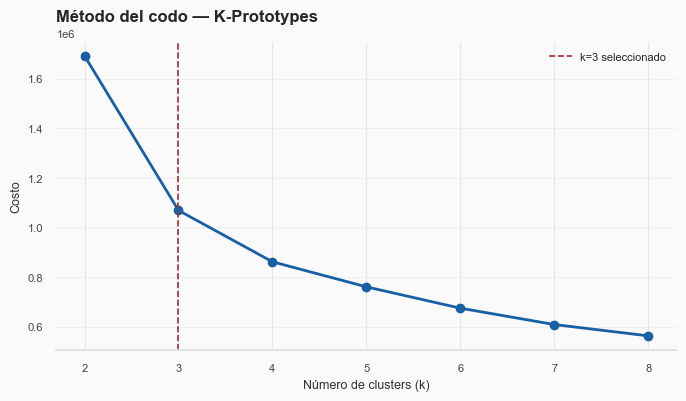

In [16]:
# Curva de codo
costos = []
ks = range(2, 9)
for k in ks:
    kp = KPrototypes(n_clusters=k, init="Huang", n_init=3, random_state=42)
    kp.fit(X, categorical=cat_idx)
    costos.append(kp.cost_)
    print(f"k={k} → costo: {kp.cost_:,.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ks), costos, color=PALETA[0], linewidth=2, marker="o", markersize=6)
ax.axvline(3, color=PALETA[1], linestyle="--", linewidth=1.2, label="k=3 seleccionado")
style_axes(
    ax,
    title="Método del codo — K-Prototypes",
    xlabel="Número de clusters (k)",
    ylabel="Costo",
    grid_axis="y",
)
ax.legend(fontsize=8, frameon=False)
plt.show()

> **Selección k=3:** La mayor caída ocurre de k=2 a k=3 (≈608.000 puntos). De k=3 en adelante la reducción es marginal y no justifica la complejidad adicional. Además k=3 produce perfiles directamente accionables para campañas: joven, adulto y mayor.

### 1.2 Modelo final

In [17]:
# Entrenar K-Prototypes k=3
kp_final = KPrototypes(n_clusters=3, init="Huang", n_init=5, random_state=42, gamma=0.5)
df["cluster"] = kp_final.fit_predict(X, categorical=cat_idx)

print("Tamaño de clusters:")
print(df["cluster"].value_counts().sort_index())
print("\nCentroides:")

centroids = kp_final.cluster_centroids_
if isinstance(centroids, (list, tuple)) and len(centroids) == 2:
    centroids_num = np.asarray(centroids[0], dtype=float)
    centroids_cat = np.asarray(centroids[1])
else:
    centroids = np.asarray(centroids)
    num_idx = [i for i in range(centroids.shape[1]) if i not in cat_idx]
    centroids_num = centroids[:, num_idx].astype(float)
    centroids_cat = centroids[:, cat_idx]

for i, (num, cat) in enumerate(zip(centroids_num, centroids_cat)):
    print(
        f"  Cluster {i}: edad={num[0]:.1f}, imc={num[1]:.1f}, rh={cat[0]}, sexo={cat[1]}, comuna={cat[2]}"
    )

Tamaño de clusters:
cluster
0     6639
1     9325
2    10143
Name: count, dtype: int64

Centroides:
  Cluster 0: edad=54.5, imc=27.0, rh=0+, sexo=m, comuna=Bello
  Cluster 1: edad=38.7, imc=27.0, rh=0+, sexo=f, comuna=Bello
  Cluster 2: edad=24.9, imc=25.3, rh=0+, sexo=f, comuna=Bello


### 1.3 Separación de características por cluster

In [18]:
# Variables numéricas
print("=" * 55)
print("SEPARACIÓN DE CARACTERÍSTICAS POR CLUSTER")
print("=" * 55)
print("\n--- NUMÉRICAS (media | mediana | std) ---")
print(df.groupby("cluster")[["edad", "imc"]].agg(["mean", "median", "std"]).round(2))

# Variables categóricas
print("\n--- CATEGÓRICAS (top 3 por cluster) ---")
for col in ["rh", "sexo", "comuna_o_municipio"]:
    print(f"\n  {col.upper()}:")
    tabla = (
        df.groupby(["cluster", col])
        .size()
        .reset_index(name="n")
        .assign(
            pct=lambda x: x.groupby("cluster")["n"]
            .transform(lambda g: g / g.sum() * 100)
            .round(1)
        )
    )
    print(
        tabla.sort_values(["cluster", "n"], ascending=[True, False])
        .groupby("cluster")
        .head(3)
        .to_string(index=False)
    )

SEPARACIÓN DE CARACTERÍSTICAS POR CLUSTER

--- NUMÉRICAS (media | mediana | std) ---
          edad                 imc             
          mean median   std   mean median   std
cluster                                        
0        54.52   54.0  4.88  27.03  26.56  3.72
1        38.70   39.0  4.18  27.02  26.45  3.99
2        24.92   25.0  3.91  25.29  24.58  3.98

--- CATEGÓRICAS (top 3 por cluster) ---

  RH:
 cluster rh    n  pct
       0 0+ 3613 54.4
       0 A+ 1590 23.9
       0 0-  706 10.6
       1 0+ 4953 53.1
       1 A+ 2419 25.9
       1 0-  860  9.2
       2 0+ 5456 53.8
       2 A+ 2646 26.1
       2 0-  786  7.7

  SEXO:
 cluster sexo    n  pct
       0    m 3344 50.4
       0    f 3295 49.6
       1    f 4902 52.6
       1    m 4423 47.4
       2    f 6229 61.4
       2    m 3914 38.6

  COMUNA_O_MUNICIPIO:
 cluster comuna_o_municipio    n  pct
       0              Bello  712 10.7
       0         16 - Belén  654  9.9
       0        7 - Robledo  455  6.9
       

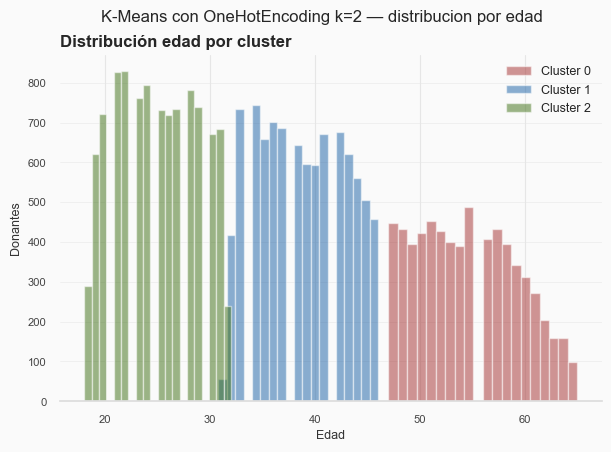

In [19]:
# Distribuciones por cluster
fig, ax = plt.subplots(figsize=(7, 4.5))

colores = {0: "#A32D2D", 1: "#185FA5", 2: "#3B6D11"}

# Edad por cluster
for c in sorted(df["cluster"].unique()):
    datos = df[df["cluster"] == c]["edad"]
    ax.hist(
        datos,
        bins=20,
        alpha=0.5,
        color=colores.get(c, colores[0]),
        label=f"Cluster {c}",
        edgecolor="white",
    )

style_axes(
    ax,
    title="Distribución edad por cluster",
    xlabel="Edad",
    ylabel="Donantes",
    grid_axis="y",
)
ax.legend(fontsize=9, frameon=False)
fig.suptitle(
    "K-Means con OneHotEncoding k=2 — distribucion por edad",
    fontsize=12,
    fontweight="500",
)
plt.show()

### 1.4 Conclusiones del clustering

**La edad es la única variable que separa los clusters de forma clara y significativa.**

| Cluster | Perfil | Edad media | Rango | Sexo dominante | Canal campaña |
|---|---|---|---|---|---|
| 1 | Joven | 24.9 años | 18–32 | Mujeres (61.4%) | Redes sociales, universidades |
| 2 | Adulto | 38.7 años | 32–47 | Mujeres (52.5%) | WhatsApp, empresas |
| 0 | Mayor | 54.5 años | 47–65 | Hombres (50.5%) | Radio, llamadas, consultorios |

**RH, IMC y comuna no diferencian los clusters** — los tres grupos tienen siempre O+ como grupo dominante (~53–54%), distribución de IMC similar (~25–27) y las mismas comunas top (Bello, Belén, Robledo). El dataset no tiene suficiente variación en esas variables para generar perfiles distintos entre grupos de edad.

**Implicación para Sanghelios:** el criterio de segmentación para campañas debe ser la **edad**, no el grupo sanguíneo ni la ubicación geográfica. El canal de comunicación debe cambiar por grupo etario, no el mensaje de fondo. Adicionalmente, O- requiere una **alerta especial permanente** independiente de cualquier cluster dado su impacto universal.

### 1.5 Guardar dataset con cluster

In [20]:
# Agregar nombre descriptivo del perfil
rangos = df.groupby("cluster")["edad"].mean()
nombres = {
    c: ("Joven (18-32)" if m < 32 else "Adulto (32-47)" if m < 45 else "Mayor (47-65)")
    for c, m in rangos.items()
}
df["perfil"] = df["cluster"].map(nombres)

# Guardar en data/processed
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "df_banco_sangre_con_cluster.csv"

df.to_csv(output_path, index=False)
print(f"Archivo guardado: {output_path}")
print(f"Columnas: {df.columns.tolist()}")
print("\nDistribucion final:")
print(
    df.groupby(["cluster", "perfil"])
    .size()
    .reset_index(name="donantes")
    .to_string(index=False)
)

Archivo guardado: c:\Users\jomig\p-REDbloodDON\data\processed\df_banco_sangre_con_cluster.csv
Columnas: ['fecha_extraccion', 'rh', 'barrio', 'ciudad', 'edad', 'sexo', 'cobertura', 'pct_poblacion', 'imc', 'comuna_o_municipio', 'año', 'mes', 'cluster', 'perfil']

Distribucion final:
 cluster         perfil  donantes
       0  Mayor (47-65)      6639
       1 Adulto (32-47)      9325
       2  Joven (18-32)     10143
